# P1: Import of the data

In [1]:
#python3.12 pip install -r /cs/home/anp4/Desktop/Recognition-of-Emotions---AI-Model/requirement.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import glob
import os
import sys
import site
import seaborn as sns
import tensorflow as tf
import cv2
from tensorflow.python.client import device_lib

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

I0000 00:00:1779901475.782147  222623 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779901477.749191  222623 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779901481.754030  222623 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import keras
print(keras.__version__)

3.14.1


In [3]:
# Source - https://stackoverflow.com/a/67504607
# Posted by Briar Campbell, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-27, License - CC BY-SA 4.0
# Check for Nvidia GPU

import subprocess

try:
    subprocess.check_output('nvidia-smi')
    print('Nvidia GPU detected\n')
    print(pd.DataFrame(subprocess.check_output('nvidia-smi').decode('utf-8').split('\n')))
except (subprocess.CalledProcessError, FileNotFoundError):
    print('No Nvidia GPU in system')
except Exception as e:
    print(f'An unexpected error occurred: {e}')

Nvidia GPU detected

                                                    0
0                     Wed May 27 18:04:55 2026       
1   +---------------------------------------------...
2   | NVIDIA-SMI 595.71.05              Driver Ver...
3   +-----------------------------------------+---...
4   | GPU  Name                 Persistence-M | Bu...
5   | Fan  Temp   Perf          Pwr:Usage/Cap |   ...
6   |                                         |   ...
7   |=========================================+===...
8   |   0  NVIDIA GeForce RTX 3060        Off |   ...
9   |  0%   53C    P8             22W /  170W |   ...
10  |                                         |   ...
11  +-----------------------------------------+---...
12                                                   
13  +---------------------------------------------...
14  | Processes:                                  ...
15  |  GPU   GI   CI              PID   Type   Pro...
16  |        ID   ID                              ...
17  |==

In [6]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU Available: []


In [4]:
def evaluate_metric(y_true, y_pred, class_names):
    
    cm = confusion_matrix(y_true, y_pred)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Affichage de la matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.show()

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    return metrics

In [5]:
train_dataset_main = "../data/train"
test_dataset_main = "../data/test"
valid_dataset_main = "..//data/valid"

In [6]:
# Tiryaki, S. (s.d.). Facial Expressions Classification. 
# Link: https://www.kaggle.com/code/sahintiryaki/facial-expressions-classification
def create_dataset_df(main_path, dataset_name):
    print(f"{dataset_name} is creating ...")
    df = {"img_path":[],"class_names":[]}
    for class_names in os.listdir(main_path):
        # Select only the emotions we want to detect.
        if class_names in {"happy", "angry", "neutral", "sad", "surprise"}:
            for img_path in glob.glob(f"{main_path}/{class_names}/*"):
                df["img_path"].append(img_path)
                df["class_names"].append(class_names)
    df = pd.DataFrame(df)
    print(f"{dataset_name} is created !")
    return df

In [7]:
train_df = create_dataset_df(train_dataset_main, "Train dataset")
train_df.size

Train dataset is creating ...
Train dataset is created !


169756

In [8]:
test_df = create_dataset_df(test_dataset_main, "Test dataset")
test_df.size

Test dataset is creating ...
Test dataset is created !


32020

In [9]:
valid_df = create_dataset_df(valid_dataset_main, "Valid dataset")
valid_df.size

Valid dataset is creating ...
Valid dataset is created !


32082

In [10]:
train_df.head()

,img_path,class_names
0,../data/train/happy/80288Exp3awe_grandmother_1...,happy
1,../data/train/happy/65014Exp3astound_worker_96...,happy
2,../data/train/happy/53132Exp3amazed_African_61...,happy
3,../data/train/happy/Happy.2985.jpg,happy
4,../data/train/happy/70972Exp3awe_student_343.jpg,happy


In [11]:
def vizualizing_images(df,n_rows,n_cols):
    plt.figure(figsize=(10,10))
    for i in range(n_rows*n_cols):
        index = np.random.randint(0, len(df))
        img = cv2.imread(df.img_path[index])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        class_nm = df.class_names[index]
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img, plt.cm.gray)
        plt.title(class_nm)
    plt.show()

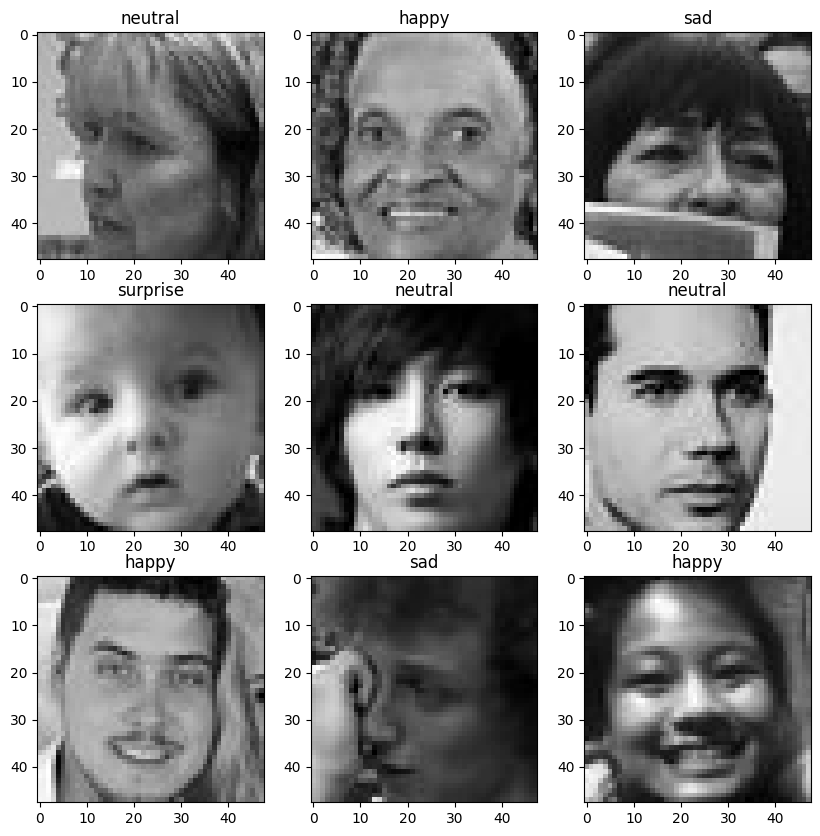

In [12]:
vizualizing_images(train_df, 3, 3)

# P2: Build the CNN (ResNet)

In [15]:
BATCH_SIZE = 64
EPOCHS = 40
IMG_CHANNEL = 3
IMG_W, IMG_H = 150, 150

In [16]:
# EfficientNet BO as a model
B_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_W, IMG_H, 3),
)

In [17]:
B_model.trainable = False

In [18]:
inputs = keras.Input(shape=(IMG_W, IMG_H, 3))

x = B_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(5, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_emotion")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "efficientnet_emotion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
# Tranning the model
train_datagen = ImageDataGenerator(
    rescale = 1/.255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# We don't need data augmentation for the validation and test sets, only rescaling.
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator with data augmentation
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='img_path',
    y_col='class_names',
    target_size=(150, 150),
    batch_size=64,
    class_mode='categorical'
)

# Validation generator
valid_generator = train_datagen.flow_from_dataframe(
    dataframe = valid_df,
    x_col = 'img_path',
    y_col = 'class_names',
    target_size=(IMG_W, IMG_H),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Test generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='img_path',
    y_col='class_names',
    target_size=(IMG_W, IMG_H),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

# Early stopping for overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Launching the training process
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=valid_generator,
    callbacks=[early_stopping]
)

Found 84878 validated image filenames belonging to 5 classes.
Found 16041 validated image filenames belonging to 5 classes.
Found 16010 validated image filenames belonging to 5 classes.
Epoch 1/40


I0000 00:00:1779899121.001785  216990 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


  57/1327 ━━━━━━━━━━━━━━━━━━━━ 8:46 414ms/step - accuracy: 0.2080 - loss: 5.2320

KeyboardInterrupt: 

In [ ]:
EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'surprise']

y_pred = model.predict(test_generator)
y_pred_classes = y_pred.argmax(axis=1)
y_true = test_generator.classes

evaluate_metric(y_true, y_pred_classes, EMOTIONS)